# Анализ распределения кафе по районам Санкт-Петербурга

## 1. Цель работы
Оценить количество объектов общественного питания (кафе) в административных районах Санкт-Петербурга.  
Построить карту с визуализацией плотности кафе по районам.

## 2. Данные и методология
- **Границы районов**: загружены из OpenStreetMap с помощью OSMnx.
- **Кафе**: загружены через OSMnx в пределах Санкт-Петербурга.
- **Пространственное соединение**: каждое кафе привязано к району, в котором оно находится.
- **Агрегация**: подсчитано количество кафе в каждом районе.
- **Визуализация**: хороплетная карта с подложкой CartoDB Positron, классификация — квантили (5 классов).

## 3. Импорт библиотек и настройки

In [1]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import contextily as cx  
import os
from shapely.ops import unary_union

## 4. Загрузка границ города и кафе

In [2]:
# границы города
city_boundary = ox.geocode_to_gdf('Санкт-Петербург, Россия')
city_polygon = city_boundary.geometry.union_all()

# кафе в пределах полигона города
cafes = ox.features_from_polygon(polygon=city_polygon, tags={'amenity': 'cafe'})
print(f'Загружено кафе: {len(cafes)}')

Загружено кафе: 3685


## 5. Загрузка и фильтрация административных границ районов

In [3]:
#  кэш данных о границах
cached_districts_path = '../data/spb_districts_raw.gpkg'

if not os.path.exists(cached_districts_path):
    print("Загружаем административные границы ...")
    districts_raw = ox.features_from_polygon(
        city_polygon,
        tags={'boundary': 'administrative', 'admin_level': '5'}
    )
    # Сохраняем сырые данные
    districts_raw.to_file(cached_districts_path, driver='GPKG')
    print(f"Границы сохранены в {cached_districts_path}")
else:
    print("Загружаем границы из кэша...")
    districts_raw = gpd.read_file(cached_districts_path)

print(f"Загружено объектов с admin_level=5: {len(districts_raw)}")

Загружаем границы из кэша...
Загружено объектов с admin_level=5: 3837


### 5.1. Фильтрация районов Санкт-Петербурга

In [4]:
# метрическая проекция для вычислений (UTM зона 36N)
utm_crs = 'EPSG:32636'
districts_raw = districts_raw.to_crs(utm_crs)
city_polygon_utm = gpd.GeoSeries([city_polygon]).set_crs(4326).to_crs(utm_crs).iloc[0]

# оставляем только полигоны
districts_poly = districts_raw[districts_raw.geom_type.isin(['Polygon', 'MultiPolygon'])].copy()

# фильтр 1: центроид внутри города
districts_poly['centroid'] = districts_poly.geometry.centroid
mask_inside = districts_poly['centroid'].within(city_polygon_utm)

# фильтр 2: в названии есть слово "район"
if 'name' not in districts_poly.columns:
    if 'name:ru' in districts_poly.columns:
        districts_poly['name'] = districts_poly['name:ru']
    else:
        districts_poly['name'] = ''
mask_name = districts_poly['name'].str.lower().str.contains('район', na=False)

# применяем оба фильтра
districts = districts_poly[mask_inside & mask_name].copy()

# удаляем временную колонку
districts.drop(columns=['centroid'], inplace=True)

# убираем возможные дубликаты по названию
districts = districts.drop_duplicates(subset='name')

print(f"Найдено районов после фильтрации: {len(districts)}")
print("Список районов:", districts['name'].tolist())

Найдено районов после фильтрации: 18
Список районов: ['Колпинский район', 'Пушкинский район', 'Московский район', 'Красносельский район', 'Петродворцовый район', 'Невский район', 'Фрунзенский район', 'Адмиралтейский район', 'Василеостровский район', 'Выборгский район', 'Калининский район', 'Кировский район', 'Красногвардейский район', 'Центральный район', 'Петроградский район', 'Кронштадтский район', 'Курортный район', 'Приморский район']


## 6. Сохранение районов

In [5]:
# сохраняем в GeoPackage
os.makedirs('data', exist_ok=True)
output_districts_path = 'data/spb_districts_clean.gpkg'
districts.to_file(output_districts_path, driver='GPKG')
print(f"Районы сохранены в {output_districts_path}")

Районы сохранены в data/spb_districts_clean.gpkg


## 7. Пространственное соединение кафе с районами

In [6]:
# приводим кафе к той же метрической проекции
cafes_utm = cafes.to_crs(utm_crs)
# пространственное соединение кафе и районов
cafes_in_districts = gpd.sjoin(cafes_utm, districts, how='inner', predicate='within')

## 8. Подсчёт количества кафе по районам

In [7]:
# группируем по индексу района
cafe_counts = cafes_in_districts.groupby('index_right').size().reset_index(name='cafe_count')

# присоединяем количество кафе к геометрии районов
districts_with_cafes = districts.merge(cafe_counts, left_index=True, right_on='index_right', how='left')
# ставим 0 в районах, где нет кафе
districts_with_cafes['cafe_count'] = districts_with_cafes['cafe_count'].fillna(0).astype(int)

print(districts_with_cafes[['name', 'cafe_count']])

                       name  cafe_count
0          Колпинский район          55
1          Пушкинский район         120
2          Московский район         230
3      Красносельский район         101
4      Петродворцовый район          42
5             Невский район         185
6         Фрунзенский район         120
7      Адмиралтейский район         468
8    Василеостровский район         255
9          Выборгский район         240
10        Калининский район         147
11          Кировский район          91
12  Красногвардейский район         134
13        Центральный район         826
14      Петроградский район         349
15      Кронштадтский район          37
16          Курортный район          51
17         Приморский район         233


## 9. Сохранение результата

In [8]:
output_dir = "../output"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, 'spb_districts_cafe.gpkg')
districts_with_cafes.to_file(output_path, driver='GPKG')
print(f"Результат сохранён в {output_path}")


Результат сохранён в ../output\spb_districts_cafe.gpkg


## 10. Визуализация хороплетной карты

Карта сохранена в ../output\cafes_map.png


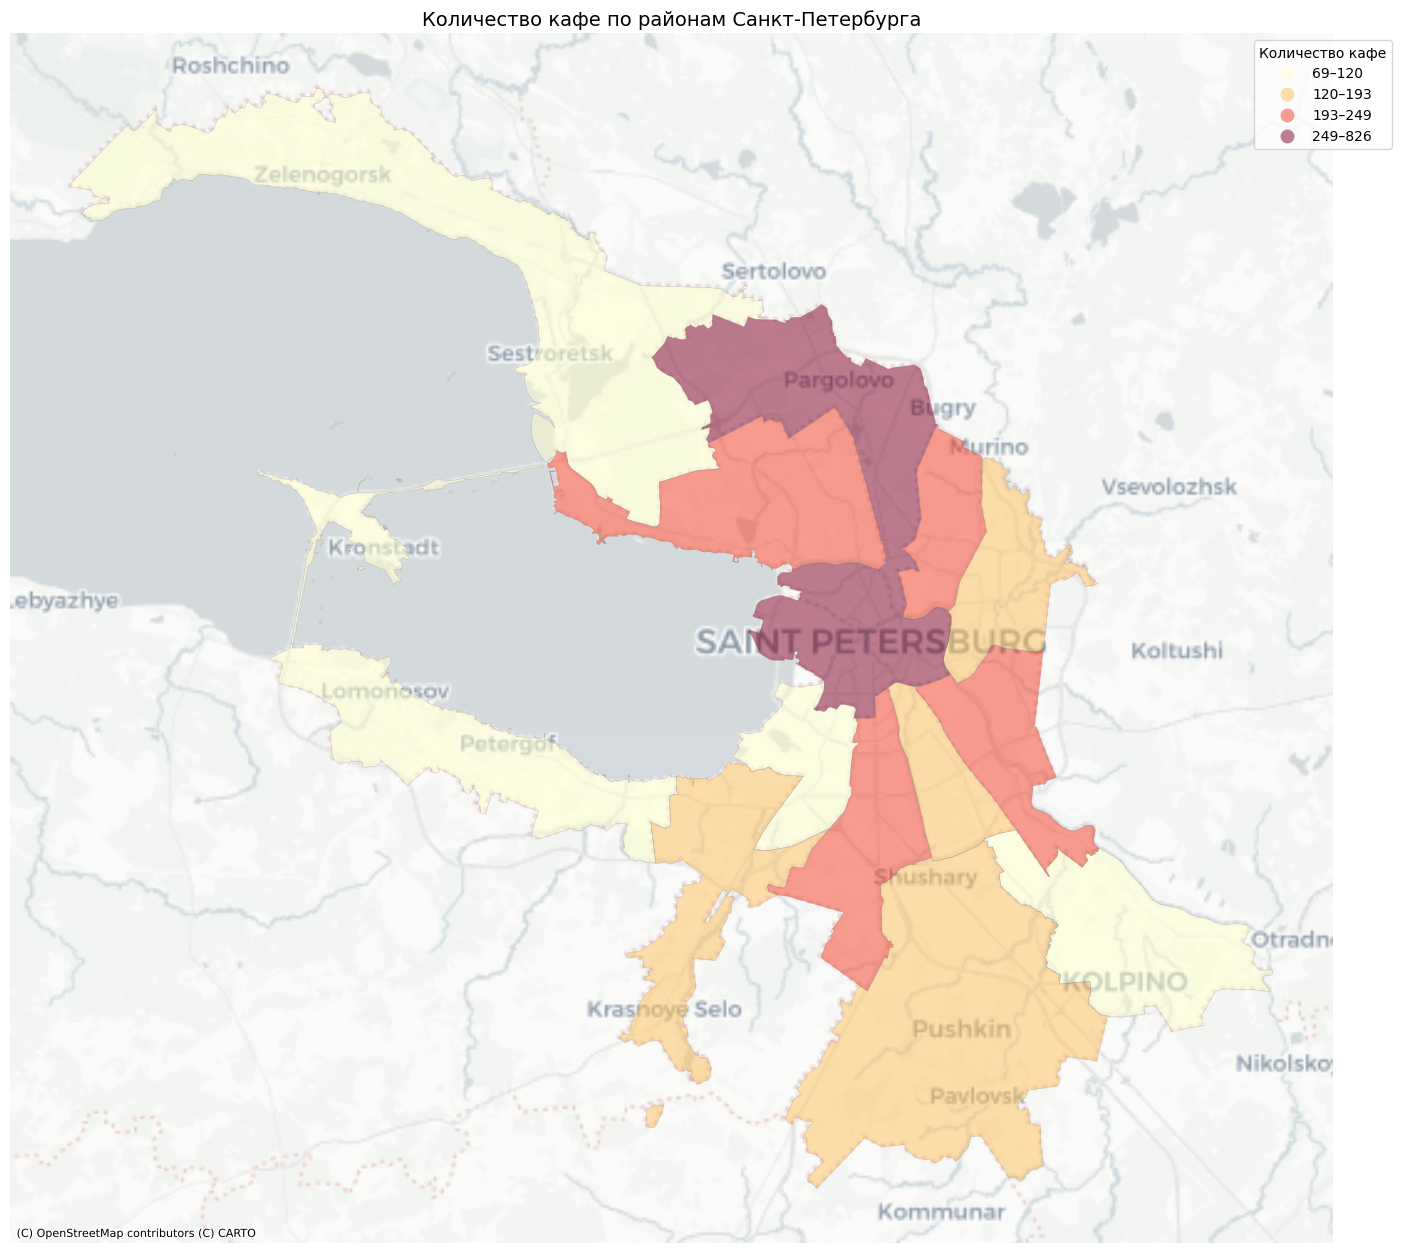

In [9]:
import mapclassify

# классификация на 5 классов
q = mapclassify.Quantiles(districts_with_cafes['cafe_count'].dropna(), k=5)
bins = q.bins
n_classes = len(bins) - 1
labels = [f"{int(bins[i])}–{int(bins[i+1])}" for i in range(n_classes)]

# преобразуем районы в Web Mercator для подложки
districts_wm = districts_with_cafes.to_crs(epsg=3857)

# создаём карту
fig, ax = plt.subplots(figsize=(14, 14))

# рисуем районы, закрашенные по количеству кафе
districts_wm.plot(
    alpha = 0.5,
    column='cafe_count',
    cmap='YlOrRd',
    scheme='Quantiles',
    k=n_classes,
    legend=True,
    edgecolor='gray',
    linewidth=0.3,
    ax=ax,
    legend_kwds={
        'title': 'Количество кафе',
        'bbox_to_anchor': (1.05, 1),
        'labels': labels
    }
)

# добавляем подложку
cx.add_basemap(ax, crs=districts_wm.crs.to_string(), source=cx.providers.CartoDB.Positron)

# сохраняем в файл
output_dir = "../output"
os.makedirs(output_dir, exist_ok=True)
filepath = os.path.join(output_dir, 'cafes_map.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight')
print(f"Карта сохранена в {filepath}")

ax.set_title('Количество кафе по районам Санкт-Петербурга', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 11. Выводы
- Всего в Санкт-Петербурге загружено **3684** объекта с тегом `amenity=cafe`.
- Распределение кафе по районам существенно различается: наибольшее количество в историческом центре и районах с высокой плотностью застройки, в то время как в отдалённых от центра районах кафе меньше.
- Карта может быть полезна для градостроительного анализа (например, для выявления дефицита точек общественного питания) или для бизнес-планирования.

In [11]:
# Вывод итоговой статистики
print("\n=== Итоговая статистика ===")
print(f"Всего кафе: {len(cafes)}")
print(f"Районов с кафе: {(districts_with_cafes['cafe_count'] > 0).sum()}")
print(f"Среднее количество кафе на район: {districts_with_cafes['cafe_count'].mean():.1f}")
print("Топ-5 районов по количеству кафе:")
print(districts_with_cafes[['name', 'cafe_count']].sort_values('cafe_count', ascending=False).head())


=== Итоговая статистика ===
Всего кафе: 3685
Районов с кафе: 18
Среднее количество кафе на район: 204.7
Топ-5 районов по количеству кафе:
                      name  cafe_count
13       Центральный район         826
7     Адмиралтейский район         468
14     Петроградский район         349
8   Василеостровский район         255
9         Выборгский район         240
